In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirm path configuration structures
print("Current Working Directory Location:", os.getcwd())

# Load your exact dataset file directly from your data folder
csv_path = "../data/student_performance_dataset.csv"
df = pd.read_csv(csv_path)

print(f"📊 Initial Raw Dataset Profile Shape: {df.shape}")
print("Columns verified:", list(df.columns))

Current Working Directory Location: d:\IBI-Student-Performance-ML\Notebook
📊 Initial Raw Dataset Profile Shape: (2500, 12)
Columns verified: ['StudentID', 'Age', 'Gender', 'AttendancePercentage', 'StudyHoursPerWeek', 'AssignmentCompletionRate', 'PreviousExamScore', 'ParticipationScore', 'ExtracurricularActivities', 'InternetAccessAtHome', 'ParentEducationLevel', 'FinalExamScore']


In [94]:
# 1. Remove duplicate values
print(f"Duplicate rows found in file: {df.duplicated().sum()}")
df = df.drop_duplicates()

# 2. Handle missing structural records (Imputation Layer)
numerical_cols = ['Age', 'AttendancePercentage', 'StudyHoursPerWeek', 'AssignmentCompletionRate', 'PreviousExamScore', 'ParticipationScore']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = ['Gender', 'ExtracurricularActivities', 'InternetAccessAtHome', 'ParentEducationLevel']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values per column after cleaning engine:", df.isnull().sum().sum())

# 3. Feature Transformation (Categorical to Numerical Maps)
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes': 1, 'No': 0})
df['InternetAccessAtHome'] = df['InternetAccessAtHome'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Set hierarchical step ranking values for education parameters
edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
df['ParentEducationLevel'] = df['ParentEducationLevel'].map(edu_map)

print(f"✅ Preprocessing Layer Clear! Current matrix shape: {df.shape}")

Duplicate rows found in file: 0
Missing values per column after cleaning engine: 0
✅ Preprocessing Layer Clear! Current matrix shape: (2500, 12)


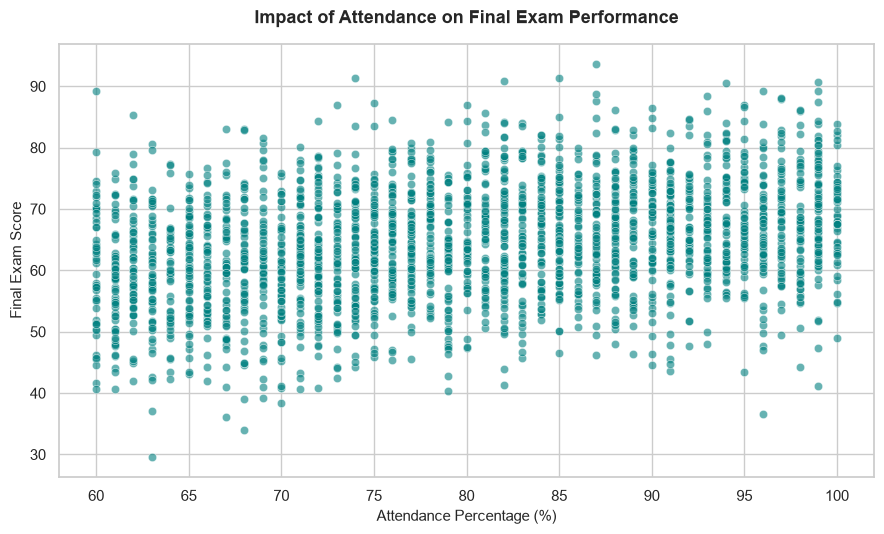

In [95]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=df, x="AttendancePercentage", y="FinalExamScore", alpha=0.6, color="teal")

plt.title("Impact of Attendance on Final Exam Performance", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Attendance Percentage (%)", fontsize=11)
plt.ylabel("Final Exam Score", fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\shamp\AppData\Local\Temp\ipykernel_24860\1088488365.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=education_score.index, y=education_score.values, palette="Blues_d")


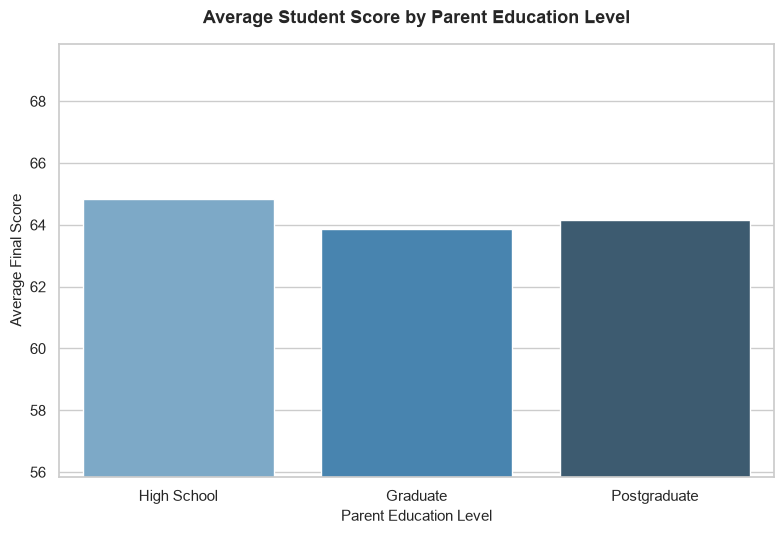

In [96]:
# Create a localized display copy to revert codes back to clear category string names
temp_plot_df = df.copy()
temp_plot_df['ParentEducationLevel'] = temp_plot_df['ParentEducationLevel'].map({1: 'High School', 2: 'Graduate', 3: 'Postgraduate'})
education_score = temp_plot_df.groupby("ParentEducationLevel")["FinalExamScore"].mean().reindex(['High School', 'Graduate', 'Postgraduate'])

plt.figure(figsize=(8, 5.5))
sns.barplot(x=education_score.index, y=education_score.values, palette="Blues_d")

# Dynamically adjust y-limits to make differences visible without distorting data
plt.ylim(max(0, education_score.min() - 8), min(100, education_score.max() + 5))
plt.title("Average Student Score by Parent Education Level", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Parent Education Level", fontsize=11)
plt.ylabel("Average Final Score", fontsize=11)
plt.tight_layout()
plt.show()

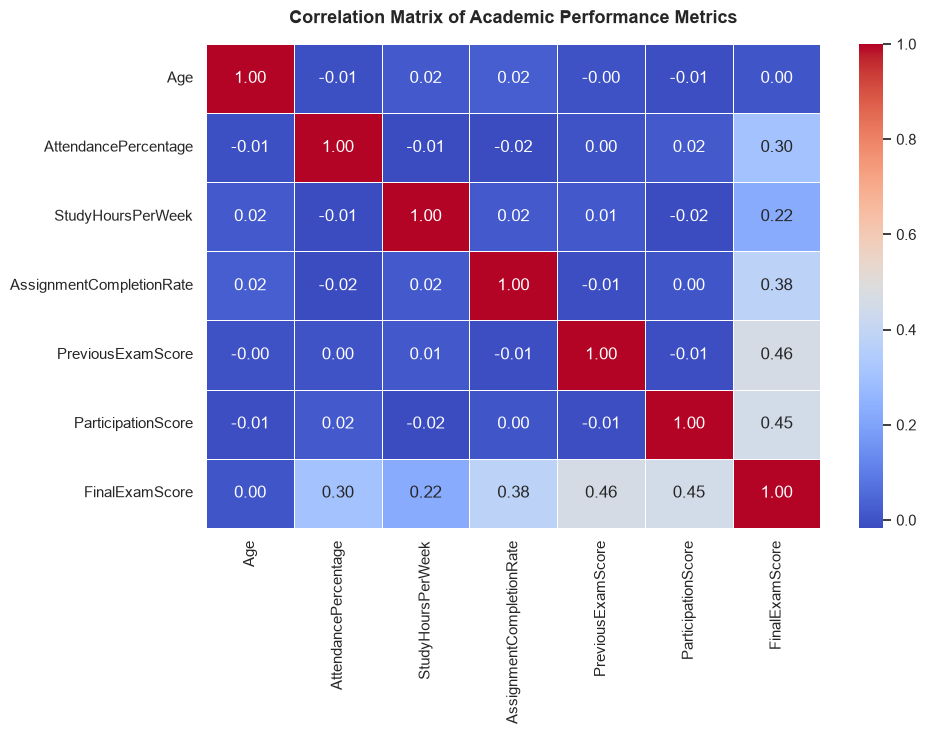

In [97]:
plt.figure(figsize=(10, 7.5))
corr_features = ['Age', 'AttendancePercentage', 'StudyHoursPerWeek', 'AssignmentCompletionRate', 'PreviousExamScore', 'ParticipationScore', 'FinalExamScore']
correlation_matrix = df[corr_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation Matrix of Academic Performance Metrics", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

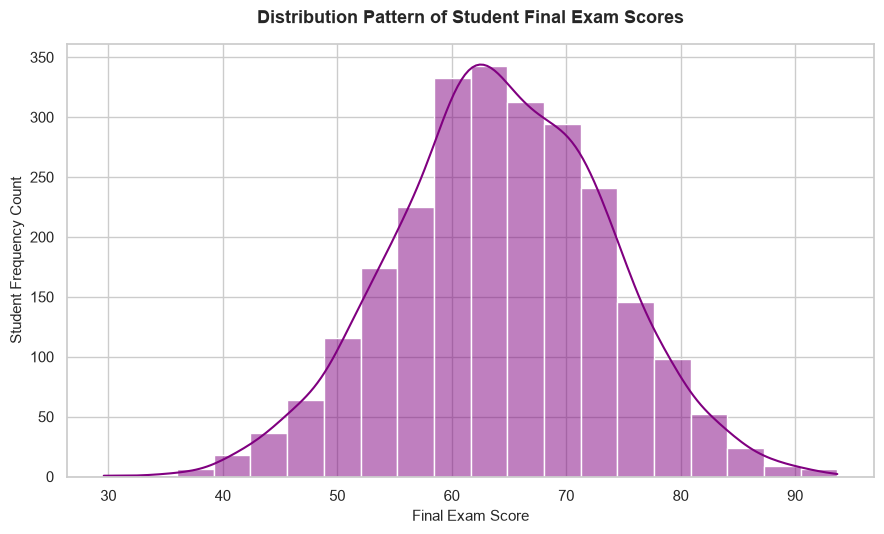

In [98]:
plt.figure(figsize=(9, 5.5))
sns.histplot(data=df, x="FinalExamScore", kde=True, color="purple", bins=20)

plt.title("Distribution Pattern of Student Final Exam Scores", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Final Exam Score", fontsize=11)
plt.ylabel("Student Frequency Count", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Train/Test Data Split Operation Layer
X = df.drop(columns=['StudentID', 'FinalExamScore'])
y = df['FinalExamScore']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Print Performance Logs
print("==== Random Forest Model Evaluation Metrics ====")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Variance Accuracy Score: {r2_score(y_test, y_pred):.2f}\n")

# 4. Polished Input Validation Protections
def get_numeric_input(prompt, min_v, max_v):
    while True:
        try:
            user_in = input(prompt).strip()
            if not user_in:
                print("⚠️ Field cannot be empty. Please enter a value.")
                continue
            val = float(user_in)
            if min_v <= val <= max_v: return val
            print(f"⚠️ Input constraint alert: Range value must sit within [{min_v} - {max_v}].")
        except ValueError:
            print("⚠️ Invalid format. Only direct numerical digits accepted.")

def get_binary_input(prompt, mapping):
    while True:
        val = input(prompt).strip().title()
        if val in mapping: return mapping[val]
        print(f"⚠️ Selection mismatch. Choose from: {list(mapping.keys())}")

# 5. Live User Console Interface Run
print("=== Custom Student Performance Interface ===")
u_attendance = get_numeric_input("Enter Attendance Percentage (0-100): ", 0.0, 100.0)
u_study = get_numeric_input("Enter Study Hours Per Week (5-40): ", 5.0, 40.0)
u_assignments = get_numeric_input("Enter Assignment Completion Rate (0-100): ", 0.0, 100.0)
u_prev_score = get_numeric_input("Enter Previous Exam Score (0-100): ", 0.0, 100.0)
u_participation = get_numeric_input("Enter Classroom Participation Score (1-10): ", 1.0, 10.0)
u_parent = get_binary_input("Enter Parent Education Level (High School/Graduate/Postgraduate): ", {'High School': 1, 'Graduate': 2, 'Postgraduate': 3})
u_extra = get_binary_input("Extracurricular Activities Participation? (Yes/No): ", {'Yes': 1, 'No': 0})
u_internet = get_binary_input("Internet Access at Home? (Yes/No): ", {'Yes': 1, 'No': 0})
u_gender = get_binary_input("Gender Identification Profile (Male/Female): ", {'Male': 1, 'Female': 0})
u_age = get_numeric_input("Enter Student Age (15-22): ", 15.0, 22.0)

user_data = pd.DataFrame([[
    u_age, u_gender, u_attendance, u_study, u_assignments,
    u_prev_score, u_participation, u_extra, u_internet, u_parent
]], columns=X.columns)

user_pred = model.predict(user_data)[0]
print("\n-------------------------------------------")
print(f"🔮 Predicted Student Performance Final Exam Score: {user_pred:.2f}%")
print("-------------------------------------------")

==== Random Forest Model Evaluation Metrics ====
Mean Absolute Error (MAE): 4.20
Mean Squared Error (MSE): 27.84
Root Mean Squared Error (RMSE): 5.28
R² Variance Accuracy Score: 0.68

=== Custom Student Performance Interface ===
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ Field cannot be empty. Please enter a value.
⚠️ 

In [ ]:
def student_performance_predictor(trained_model, feature_columns):
    print("\n=============================================")
    print("🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓")
    print("=============================================\n")
    print("Please enter the student's details below to predict their final score.")
    
    try:
        # 1. Gather numerical inputs with safety limits
        attendance = float(input("Enter Attendance Percentage (0 to 100): "))
        if not (0 <= attendance <= 100):
            print("❌ Error: Attendance percentage must be between 0 and 100.")
            return

        study_hours = float(input("Enter Average Study Hours Per Week (e.g., 0 to 50): "))
        if study_hours < 0:
            print("❌ Error: Study hours cannot be negative.")
            return

        assignment_rate = float(input("Enter Assignment Completion Rate (0 to 100): "))
        if not (0 <= assignment_rate <= 100):
            print("❌ Error: Assignment rate must be between 0 and 100.")
            return

        prev_score = float(input("Enter Previous Exam Score (0 to 100): "))
        if not (0 <= prev_score <= 100):
            print("❌ Error: Previous exam score must be between 0 and 100.")
            return

        participation = float(input("Enter Classroom Participation Score (0 to 100): "))
        if not (0 <= participation <= 100):
            print("❌ Error: Participation score must be between 0 and 100.")
            return
            
        age = float(input("Enter Student Age: "))
        if age <= 0:
            print("❌ Error: Age must be a positive number.")
            return

        # 2. Gather categorical inputs and manually map them to match training
        gender_input = input("Enter Gender (Male/Female): ").strip().capitalize()
        if gender_input not in ['Male', 'Female']:
            print("❌ Error: Gender must be 'Male' or 'Female'.")
            return
        gender = 1 if gender_input == 'Male' else 0

        extra_input = input("Involved in Extracurricular Activities? (Yes/No): ").strip().capitalize()
        if extra_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        extracurricular = 1 if extra_input == 'Yes' else 0

        internet_input = input("Has Internet Access At Home? (Yes/No): ").strip().capitalize()
        if internet_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        internet = 1 if internet_input == 'Yes' else 0

        print("\nParent Education levels: 'High School', 'Graduate', 'Postgraduate'")
        edu_input = input("Enter Parent Education Level: ").strip().title()
        edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
        if edu_input not in edu_map:
            print("❌ Error: Invalid education level entered.")
            return
        parent_edu = edu_map[edu_input]

        # 3. Structure the input data row to precisely match the model's feature alignment
        # Construct dictionary mapping feature names to user input variables
        user_data_dict = {
            'Age': age,
            'Gender': gender,
            'AttendancePercentage': attendance,
            'StudyHoursPerWeek': study_hours,
            'AssignmentCompletionRate': assignment_rate,
            'PreviousExamScore': prev_score,
            'ParticipationScore': participation,
            'ExtracurricularActivities': extracurricular,
            'InternetAccessAtHome': internet,
            'ParentEducationLevel': parent_edu
        }
        
        # Build array strictly in the correct column order from training (X)
        input_features = [user_data_dict[col] for col in feature_columns]
        
        # 4. Generate and display the prediction
        predicted_score = trained_model.predict([input_features])[0]
        
        # Clamp bounds to valid scale 0-100% just in case
        predicted_score = max(0, min(100, predicted_score))
        
        print("\n=============================================")
        print(f"🔮 Predicted Final Exam Score: {predicted_score:.1f}%")
        print("=============================================")

    except ValueError:
        print("\n❌ Error: Invalid numerical entry. Please enter valid numbers.")

# Run the console interface! 
# We pass the model and the exact training columns order list (X.columns)
student_performance_predictor(model, list(X.columns))


❌ Error: Invalid numerical entry. Please enter valid numbers.


In [ ]:

import warnings

def student_performance_predictor(trained_model, feature_columns):
    print("\n=============================================")
    print("🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓")
    print("=============================================\n")
    print("Please enter the student's details below to predict their final score.")
    
    try:
        # 1. Gather numerical inputs with safety limits
        attendance = float(input("Enter Attendance Percentage (0 to 100): "))
        if not (0 <= attendance <= 100):
            print("❌ Error: Attendance percentage must be between 0 and 100.")
            return

        study_hours = float(input("Enter Average Study Hours Per Week (e.g., 0 to 50): "))
        if study_hours < 0:
            print("❌ Error: Study hours cannot be negative.")
            return

        assignment_rate = float(input("Enter Assignment Completion Rate (0 to 100): "))
        if not (0 <= assignment_rate <= 100):
            print("❌ Error: Assignment rate must be between 0 and 100.")
            return

        prev_score = float(input("Enter Previous Exam Score (0 to 100): "))
        if not (0 <= prev_score <= 100):
            print("❌ Error: Previous exam score must be between 0 and 100.")
            return

        participation = float(input("Enter Classroom Participation Score (0 to 100): "))
        if not (0 <= participation <= 100):
            print("❌ Error: Participation score must be between 0 and 100.")
            return
            
        age = float(input("Enter Student Age: "))
        if age <= 0:
            print("❌ Error: Age must be a positive number.")
            return

        # 2. Gather categorical inputs and manually map them to match training
        gender_input = input("Enter Gender (Male/Female): ").strip().capitalize()
        if gender_input not in ['Male', 'Female']:
            print("❌ Error: Gender must be 'Male' or 'Female'.")
            return
        gender = 1 if gender_input == 'Male' else 0

        extra_input = input("Involved in Extracurricular Activities? (Yes/No): ").strip().capitalize()
        if extra_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        extracurricular = 1 if extra_input == 'Yes' else 0

        internet_input = input("Has Internet Access At Home? (Yes/No): ").strip().capitalize()
        if internet_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        internet = 1 if internet_input == 'Yes' else 0

        print("\nParent Education levels: 'High School', 'Graduate', 'Postgraduate'")
        edu_input = input("Enter Parent Education Level: ").strip().title()
        edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
        if edu_input not in edu_map:
            print("❌ Error: Invalid education level entered.")
            return
        parent_edu = edu_map[edu_input]

        # 3. Structure the input data row to precisely match the model's feature alignment
        user_data_dict = {
            'Age': age,
            'Gender': gender,
            'AttendancePercentage': attendance,
            'StudyHoursPerWeek': study_hours,
            'AssignmentCompletionRate': assignment_rate,
            'PreviousExamScore': prev_score,
            'ParticipationScore': participation,
            'ExtracurricularActivities': extracurricular,
            'InternetAccessAtHome': internet,
            'ParentEducationLevel': parent_edu
        }
        
        # Create a single-row DataFrame using training column order to eliminate Scikit-Learn warnings
        input_df = pd.DataFrame([user_data_dict], columns=feature_columns)
        
        # 4. Generate and display the prediction
        predicted_score = trained_model.predict(input_df)[0]
        predicted_score = max(0, min(100, predicted_score)) # Clamp bounds 0-100%
        
        print("\n=============================================")
        print(f"🔮 Predicted Final Exam Score: {predicted_score:.1f}%")
        print("=============================================")

    except ValueError:
        print("\n❌ Error: Invalid numerical entry. Please enter valid numbers.")

# Run the console interface! 
student_performance_predictor(model, list(X.columns))


🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓

Please enter the student's details below to predict their final score.

❌ Error: Invalid numerical entry. Please enter valid numbers.
